## OptimESM Work Package 5: Sea Ice Figures

### Description:

Notebook containing plots of Sea Ice diagnostics for OptimESM idealised experiments.

### Created By:

Ollie Tooth (oliver.tooth@noc.ac.uk)

In [1]:
# -- Import dependencies -- #
import glob
import cftime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# -- Update matplotlib defaults -- #
plt.rcParams.update({
    # Figure
    "figure.figsize": (6.5, 4.0),          # Good for reports (inches)
    "figure.dpi": 500,                     # High resolution for raster export
    "savefig.dpi": 500,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,

    # Fonts
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Axes
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,

    # Lines
    "lines.linewidth": 1.8,
    "lines.markersize": 5,

    # Legend
    "legend.frameon": False,
})


### **Utility Functions**

In [2]:
def open_diagnostic_dataset(filepath: str, offset: int = 0):
    """
    Open NEMO Pipeline Diagnostic Dataset.

    Parameters
    ----------
    filepath : str
        Filepath to NEMO Pipeline diagnostics stored in local netCDF file.
    offset : int
        Offset used to adjust (add) time_counter coordinate.

    Returns
    -------
    ds : xr.Dataset
    """
    # Define CF-timecoder:
    time_coder = xr.coders.CFDatetimeCoder(time_unit="s")
    # Open diagnostic netCDF dataset:
    ds = xr.open_dataset(filepath, decode_times=time_coder)

    # Update time_counter coord using cftime:
    new_time_counter = [
        cftime.Datetime360Day(t.year - ds['time_counter'].values[0].year + offset,
                              t.month,
                              t.day
                              )
        for t in ds['time_counter'].values
    ]
    ds = ds.assign_coords(time_counter=("time_counter", new_time_counter))

    return ds

# UKESM1-2-LL

### **UKESM1-2-LL:** Sea Ice Area

In [3]:
# -- Define filepaths -- #
ukesm1_dir = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/siarea"
ukesm1_fnames = "UKESM1-2-LL_*_r1i1p1f1_siarea_*.nc"

ukesm1_fpaths = sorted(glob.glob(f"{ukesm1_dir}/{ukesm1_fnames}"))
ukesm1_fpaths


['/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/siarea/UKESM1-2-LL_esm-hist_r1i1p1f1_siarea_1850-01-2014-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/siarea/UKESM1-2-LL_esm-piControl_r1i1p1f1_siarea_2100-01-2500-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/siarea/UKESM1-2-LL_esm-up2p0-gwl2p0-50y-dn1p0_r1i1p1f1_siarea_1994-01-2053-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/siarea/UKESM1-2-LL_esm-up2p0-gwl2p0-50y-dn2p0_r1i1p1f1_siarea_1994-01-2127-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/siarea/UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_siarea_1944-01-2444-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/siarea/UKESM1-2-LL_esm-up2p0-gwl3p0-50y-dn2p0_r1i1p1f1_siarea_2044-01-2126-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/siarea/UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_siarea_1992-01-2411-12.nc',
 '/g100_

In [4]:
# -- Variable -- #
var_name = 'siarea'

# -- Pre-Processing esm-piControl -- #
ds_ukmo_piControl = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-piControl_r1i1p1f1_{var_name}_2100-01-2500-12.nc")

# -- Pre-Processing esm-gwl[2,3,4] -- #
ds_ukmo_gwl2p0 = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_{var_name}_1944-01-2444-12.nc", offset=1944-1850)
ds_ukmo_gwl3p0 = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_{var_name}_1992-01-2411-12.nc", offset=1992-1850)
ds_ukmo_gwl4p0 = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_{var_name}_2044-01-2544-12.nc", offset=2044-1850)


# EC-Earth3-ESM-1

### **EC-Earth3-ESM1:** Sea Ice Area

In [5]:
# -- Define filepaths -- #
ecearth_dir = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/siarea"
ecearth_fnames = "EC-Earth3-ESM-1_*_r1i1p1f1_siarea_*.nc"

ecearth_fpaths = sorted(glob.glob(f"{ecearth_dir}/{ecearth_fnames}"))
ecearth_fpaths = sorted([path for path in ecearth_fpaths if '-dn' not in path])
ecearth_fpaths


['/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/siarea/EC-Earth3-ESM-1_esm-hist_r1i1p1f1_siarea_1850-01-2014-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/siarea/EC-Earth3-ESM-1_esm-piControl_r1i1p1f1_siarea_1850-01-2450-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/siarea/EC-Earth3-ESM-1_esm-up2p0-gwl1p5_r1i1p1f1_siarea_1926-01-2225-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/siarea/EC-Earth3-ESM-1_esm-up2p0-gwl2p0_r1i1p1f1_siarea_1951-01-2450-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/siarea/EC-Earth3-ESM-1_esm-up2p0-gwl3p0_r1i1p1f1_siarea_2001-01-2300-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/siarea/EC-Earth3-ESM-1_esm-up2p0-gwl4p0_r1i1p1f1_siarea_2051-01-2550-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/siarea/EC-Earth3-ESM-1_esm-up2p0-gwl5p0_r1i1p1f1_siarea_2101-01-2400-12.nc',
 '/g100_wo

In [6]:
time_coder = xr.coders.CFDatetimeCoder(time_unit="s")

# -- Pre-Processing esm-piControl -- #
ds_ec_piControl = xr.open_dataset(ecearth_fpaths[1], decode_times=time_coder)

# -- Pre-Processing esm-gwl[1.5,2,3,4,5,6] -- #
ds_ec_gwl1p5 = xr.open_dataset(ecearth_fpaths[2], decode_times=time_coder)
ds_ec_gwl2p0 = xr.open_dataset(ecearth_fpaths[3], decode_times=time_coder)
ds_ec_gwl3p0 = xr.open_dataset(ecearth_fpaths[4], decode_times=time_coder)
ds_ec_gwl4p0 = xr.open_dataset(ecearth_fpaths[5], decode_times=time_coder)
ds_ec_gwl5p0 = xr.open_dataset(ecearth_fpaths[6], decode_times=time_coder)
ds_ec_gwl6p0 = xr.open_dataset(ecearth_fpaths[7], decode_times=time_coder)

# IPSL-CM6-ESMCO2

### **IPSL-CM6-ESMCO2:** Sea Ice Area

In [7]:
# -- Define filepaths -- #
ipsl_dir = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/siarea"
ipsl_fnames = "IPSL-CM6-ESMCO2_*_r1i1p3f1_siarea_*.nc"

ipsl_fpaths = sorted(glob.glob(f"{ipsl_dir}/{ipsl_fnames}"))
ipsl_fpaths = sorted([path for path in ipsl_fpaths if '-dn' not in path])
ipsl_fpaths


['/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/siarea/IPSL-CM6-ESMCO2_esm-hist_r1i1p3f1_siarea_1850-01-2014-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/siarea/IPSL-CM6-ESMCO2_esm-piControl_r1i1p3f1_siarea_1800-01-2349-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/siarea/IPSL-CM6-ESMCO2_esm-up2p0-gwl1p5_r1i1p3f1_siarea_1950-01-2239-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/siarea/IPSL-CM6-ESMCO2_esm-up2p0-gwl2p0_r1i1p3f1_siarea_1979-01-2398-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/siarea/IPSL-CM6-ESMCO2_esm-up2p0-gwl3p0_r1i1p3f1_siarea_2041-01-2460-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/siarea/IPSL-CM6-ESMCO2_esm-up2p0-gwl4p0_r1i1p3f1_siarea_2098-01-2357-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/siarea/IPSL-CM6-ESMCO2_esm-up2p0_r1i1p3f1_siarea_1850-01-2329-12.nc']

In [8]:
time_coder = xr.coders.CFDatetimeCoder(time_unit="s")

# -- Pre-Processing esm-piControl -- #
ds_ipsl_piControl = xr.open_dataset(ipsl_fpaths[1], decode_times=time_coder).sel(time_counter=slice('1850', None))

# -- Pre-Processing esm-gwl[2,3,4] -- #
ds_ipsl_gwl1p5 = xr.open_dataset(ipsl_fpaths[2], decode_times=time_coder)
ds_ipsl_gwl2p0 = xr.open_dataset(ipsl_fpaths[3], decode_times=time_coder)
ds_ipsl_gwl3p0 = xr.open_dataset(ipsl_fpaths[4], decode_times=time_coder)
ds_ipsl_gwl4p0 = xr.open_dataset(ipsl_fpaths[5], decode_times=time_coder)


## Figure

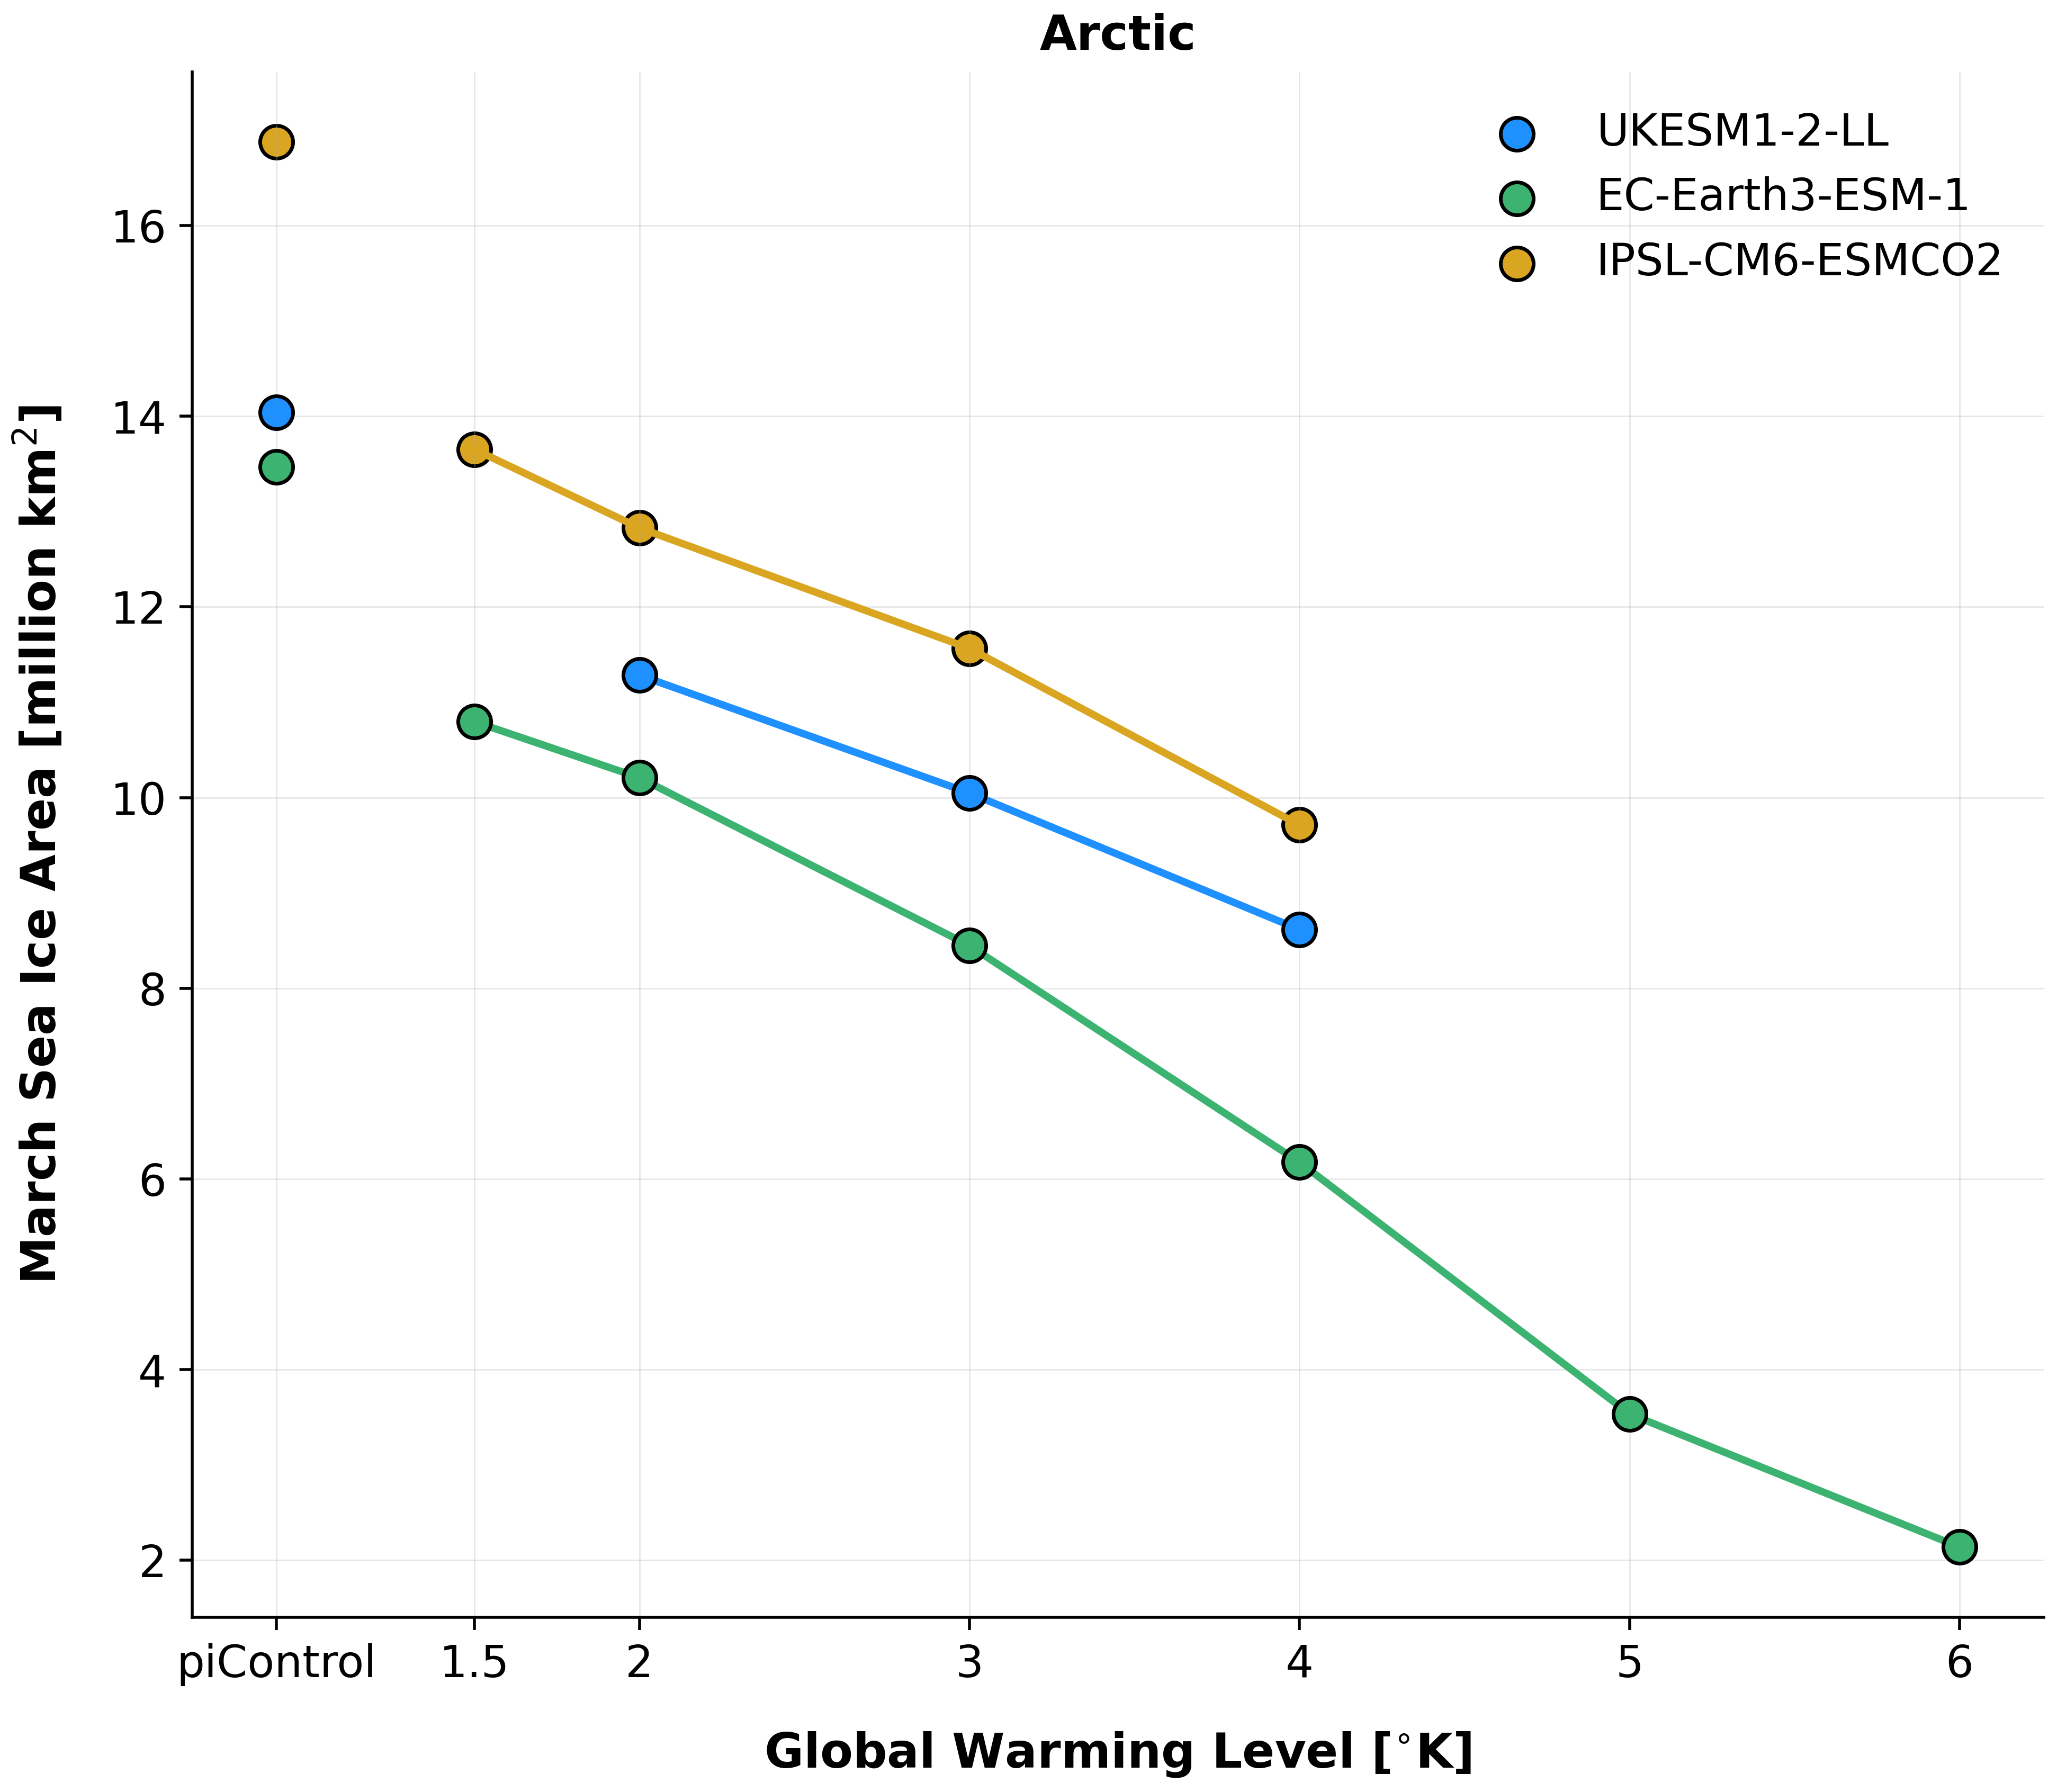

In [9]:
# -- Figure -- #
fig, ax = plt.subplots(figsize=(8, 7))

# Define variable to plot:
plot_var_name = 'siarea_NH'
month = 3 # March

# Define common scatter plot properties:
size=80
edgecolor='k'

# -- UKESM1 -- #
gwl = [0.9, 2, 3, 4]
values = [ds_ukmo_piControl[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ukmo_gwl2p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ukmo_gwl3p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ukmo_gwl4p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12
          ]
plt.plot(gwl[1:], values[1:], linewidth=2, color='dodgerblue', zorder=2)
plt.scatter(gwl, values, s=size, color='dodgerblue', edgecolor=edgecolor, label='UKESM1-2-LL', zorder=3)

# -- EC-Earth3 -- #
gwl = [0.9, 1.5, 2, 3, 4, 5, 6]
values = [ds_ec_piControl[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl1p5[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl2p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl3p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl4p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl5p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl6p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12
          ]
plt.plot(gwl[1:], values[1:], linewidth=2, color='mediumseagreen', zorder=2)
plt.scatter(gwl, values, s=size, color='mediumseagreen', edgecolor=edgecolor, label='EC-Earth3-ESM-1', zorder=3)

# -- IPSL -- #
gwl = [0.9, 1.5, 2, 3, 4]
values = [ds_ipsl_piControl[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ipsl_gwl1p5[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ipsl_gwl2p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ipsl_gwl3p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ipsl_gwl4p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12
          ]
plt.plot(gwl[1:], values[1:], linewidth=2, color='goldenrod', zorder=2)
plt.scatter(gwl, values, s=size, color='goldenrod', edgecolor=edgecolor, label='IPSL-CM6-ESMCO2')

# Configure Axes:
ax.set_title("Arctic", fontdict={'size': 13, 'weight': 'bold'})
ax.set_xticks([0.9, 1.5, 2, 3, 4, 5, 6], labels=['piControl', '1.5', '2', '3', '4', '5', '6'])
ax.set_xlabel("Global Warming Level [$^{\\circ}$K]", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.set_ylabel("March Sea Ice Area [million km$^{2}$]", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(ncols=1, fontsize=12)

# Subtle grid styling
ax.grid(which="major", linestyle='-', linewidth=0.4, alpha=0.3)
ax.grid(which="minor", linestyle=':', linewidth=0.3, alpha=0.2)

# Clean spines (modern look)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tight layout
fig.tight_layout()
# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_M26_Arctic_sea_ice_area_gwl.png", bbox_inches='tight', dpi=600)


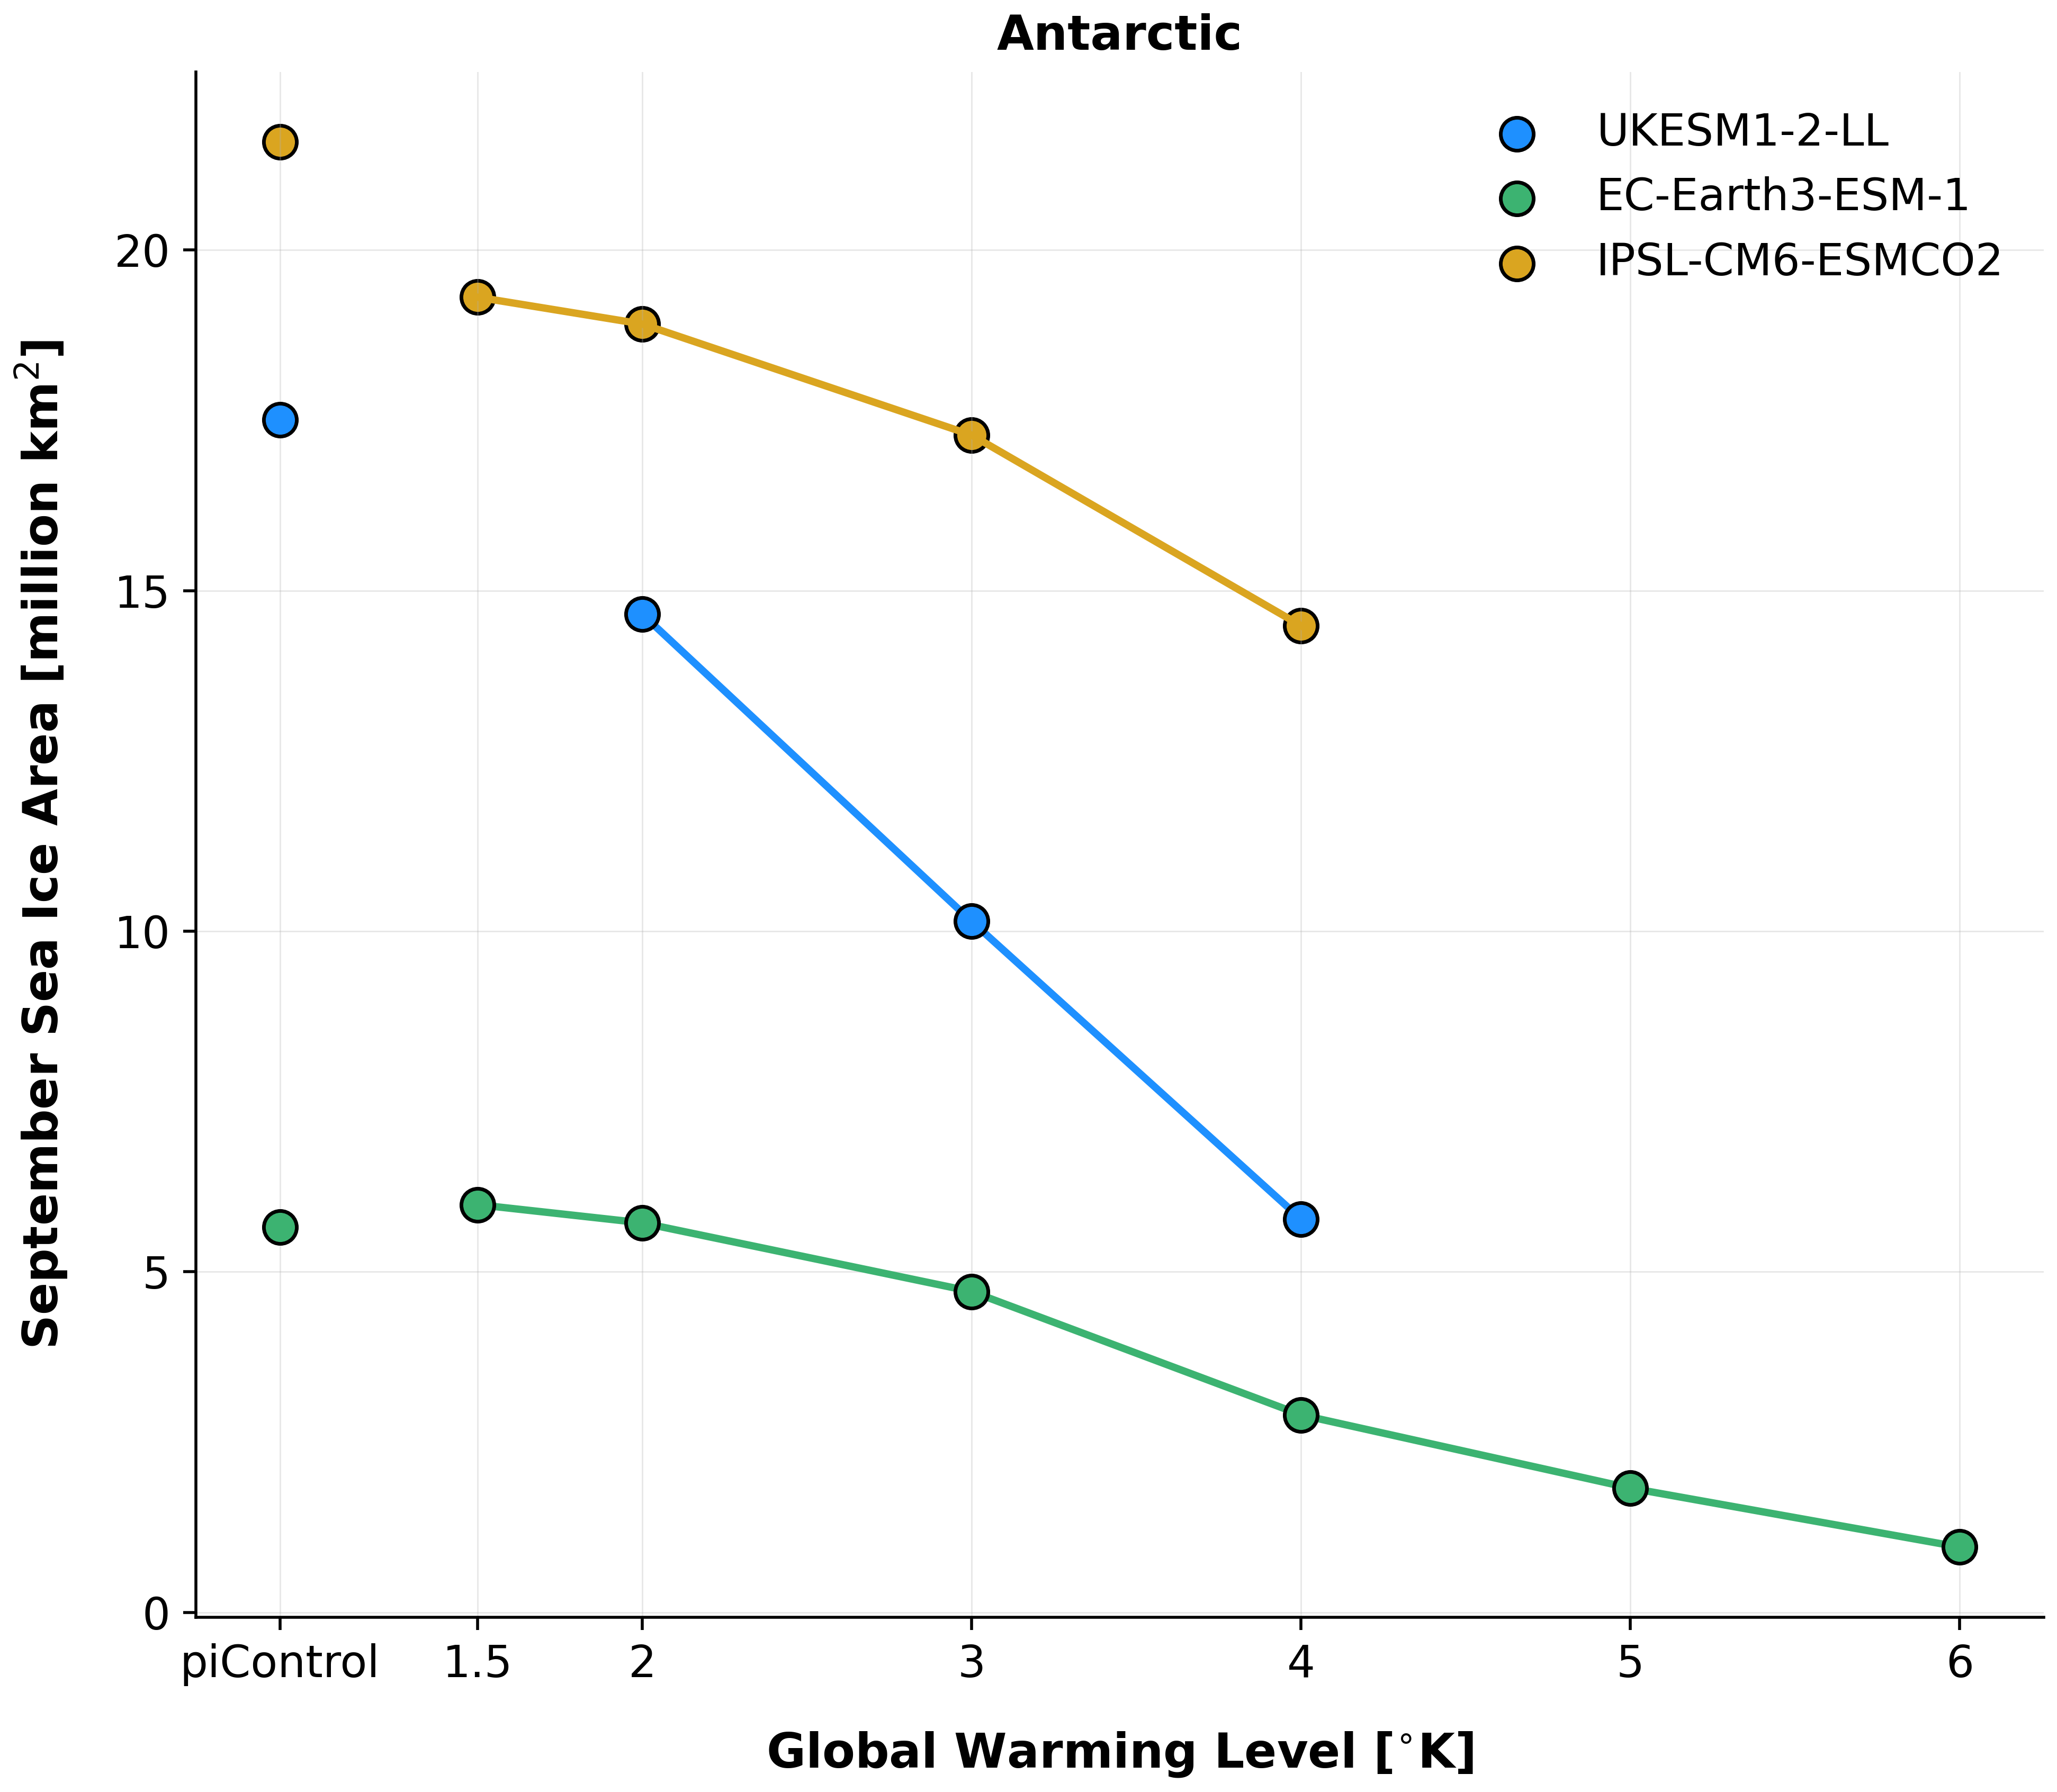

In [10]:
# -- Figure -- #
fig, ax = plt.subplots(figsize=(8, 7))

# Define variable to plot:
plot_var_name = 'siarea_SH'
month = 9 # September

# Define common scatter plot properties:
size=80
edgecolor='k'

# -- UKESM1 -- #
gwl = [0.9, 2, 3, 4]
values = [ds_ukmo_piControl[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ukmo_gwl2p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ukmo_gwl3p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ukmo_gwl4p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12
          ]
plt.plot(gwl[1:], values[1:], linewidth=2, color='dodgerblue', zorder=2)
plt.scatter(gwl, values, s=size, color='dodgerblue', edgecolor=edgecolor, label='UKESM1-2-LL', zorder=3)

# -- EC-Earth3 -- #
gwl = [0.9, 1.5, 2, 3, 4, 5, 6]
values = [ds_ec_piControl[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl1p5[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl2p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl3p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl4p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl5p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ec_gwl6p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12
          ]
plt.plot(gwl[1:], values[1:], linewidth=2, color='mediumseagreen', zorder=2)
plt.scatter(gwl, values, s=size, color='mediumseagreen', edgecolor=edgecolor, label='EC-Earth3-ESM-1', zorder=3)

# -- IPSL -- #
gwl = [0.9, 1.5, 2, 3, 4]
values = [ds_ipsl_piControl[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ipsl_gwl1p5[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ipsl_gwl2p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ipsl_gwl3p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12,
          ds_ipsl_gwl4p0[plot_var_name].isel(time_counter=slice(month-1, None, 12)).mean(dim='time_counter') / 1E12
          ]
plt.plot(gwl[1:], values[1:], linewidth=2, color='goldenrod', zorder=2)
plt.scatter(gwl, values, s=size, color='goldenrod', edgecolor=edgecolor, label='IPSL-CM6-ESMCO2')

# Configure Axes:
ax.set_title("Antarctic", fontdict={'size': 13, 'weight': 'bold'})
ax.set_xticks([0.9, 1.5, 2, 3, 4, 5, 6], labels=['piControl', '1.5', '2', '3', '4', '5', '6'])
ax.set_xlabel("Global Warming Level [$^{\\circ}$K]", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.set_ylabel("September Sea Ice Area [million km$^{2}$]", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(ncols=1, fontsize=12)

# Subtle grid styling
ax.grid(which="major", linestyle='-', linewidth=0.4, alpha=0.3)
ax.grid(which="minor", linestyle=':', linewidth=0.3, alpha=0.2)

# Clean spines (modern look)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tight layout
fig.tight_layout()
# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_M26_Antarctic_sea_ice_area_gwl.png", bbox_inches='tight', dpi=600)
